In [15]:
import sys
import os

# Add the project root (where the nn/ folder lives) to the import path
sys.path.insert(0, os.path.abspath('../..'))

# Now you can import from nn
from nn import network
from nn import mnist_loader

In [16]:
import numpy as np
import matplotlib.pyplot as plt

train_data, validation_data, test_data = mnist_loader.load_data_wrapper("../../nn/mnist.pkl.gz")
train_data = list(train_data)
validation_data = list(validation_data)
test_data = list(test_data)

network1_accuracies = []

net = network.Network([784, 15, 10])
for _ in range(30):
    net.SGD(train_data, 1, 10, 3.0, test_data=test_data)
    network1_accuracies.append(net.evaluate(test_data) / len(test_data))
    print(network1_accuracies)

network2_accuracies = []

net = network.Network([784, 16, 16, 10])
for _ in range(30):
    net.SGD(training_data, 1, 10, 3.0, test_data=test_data)
    network2_accuracies.append(net.evaluate(test_data) / len(test_data))
    print(network2_accuracies)

Epoch 0 : 8932 / 10000 [949/980 1108/1135]
[0.8932]
Epoch 0 : 9106 / 10000 [942/980 1096/1135]
[0.8932, 0.9106]
Epoch 0 : 9206 / 10000 [959/980 1108/1135]
[0.8932, 0.9106, 0.9206]
Epoch 0 : 9247 / 10000 [961/980 1102/1135]
[0.8932, 0.9106, 0.9206, 0.9247]
Epoch 0 : 9207 / 10000 [962/980 1106/1135]
[0.8932, 0.9106, 0.9206, 0.9247, 0.9207]
Epoch 0 : 9276 / 10000 [948/980 1103/1135]
[0.8932, 0.9106, 0.9206, 0.9247, 0.9207, 0.9276]
Epoch 0 : 9266 / 10000 [966/980 1098/1135]
[0.8932, 0.9106, 0.9206, 0.9247, 0.9207, 0.9276, 0.9266]
Epoch 0 : 9334 / 10000 [955/980 1111/1135]
[0.8932, 0.9106, 0.9206, 0.9247, 0.9207, 0.9276, 0.9266, 0.9334]
Epoch 0 : 9337 / 10000 [960/980 1107/1135]
[0.8932, 0.9106, 0.9206, 0.9247, 0.9207, 0.9276, 0.9266, 0.9334, 0.9337]
Epoch 0 : 9324 / 10000 [960/980 1110/1135]
[0.8932, 0.9106, 0.9206, 0.9247, 0.9207, 0.9276, 0.9266, 0.9334, 0.9337, 0.9324]
Epoch 0 : 9308 / 10000 [959/980 1109/1135]
[0.8932, 0.9106, 0.9206, 0.9247, 0.9207, 0.9276, 0.9266, 0.9334, 0.9337, 0.93

In [17]:
#calculate the averages
#step 1- initialize the sums of all the darkness of all the digits to 0
darknesses = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
counts = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
for i in range(len(train_data)):
    x, y = train_data[i]
    digit = np.argmax(y)
    darknesses[digit] += np.sum(x)
    counts[digit] += 1

print(darknesses)
print(counts)

darkaverages = [darknesses[i] / counts[i] for i in range(10)]
print(darkaverages)

correct = 0

#determining accuracies on the test set for each digit
for i in range(len(test_data)):
    x, y = test_data[i]
    darkx = np.sum(x)
    digit = np.argmax(y) 
    diffs = [abs(darkx - darkaverages[i]) for i in range(10)]
    predicted_digit = np.argmin(diffs)
    if predicted_digit == digit:
        correct += 1

acc = correct / len(test_data)
print(acc)

[np.float32(670105.44), np.float32(338751.56), np.float32(577750.75), np.float32(565552.3), np.float32(462677.4), np.float32(452161.62), np.float32(531654.1), np.float32(465123.3), np.float32(570777.94), np.float32(479075.66)]
[4932, 5678, 4968, 5101, 4859, 4506, 4951, 5175, 4842, 4988]
[np.float32(135.86891), np.float32(59.660366), np.float32(116.29443), np.float32(110.87087), np.float32(95.2207), np.float32(100.346565), np.float32(107.38318), np.float32(89.8789), np.float32(117.880615), np.float32(96.04564)]
0.2322


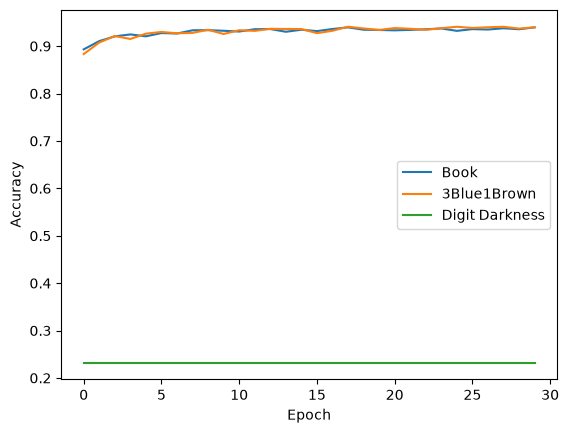

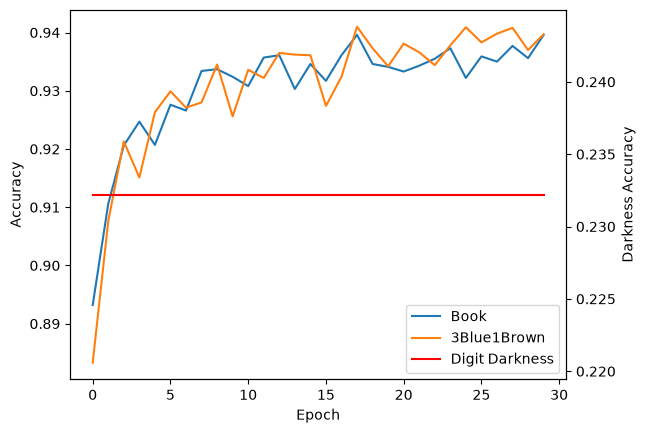

In [19]:
import matplotlib.pyplot as plt

darkaccs = [acc for _ in range(30)]

plt.plot(range(30), network1_accuracies, label='Book')
plt.plot(range(30), network2_accuracies, label='3Blue1Brown')
plt.plot(range(30), darkaccs, label='Digit Darkness')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

fig, ax1 = plt.subplots()
ax1.plot(range(30), network1_accuracies, label='Book')
ax1.plot(range(30), network2_accuracies, label='3Blue1Brown')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')

ax2 = ax1.twinx()
ax2.plot(range(30), darkaccs, label='Digit Darkness', color='red')
ax2.set_ylabel('Darkness Accuracy')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2)
plt.show()